<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Lan%C3%A7amentos_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas Phyton

In [1]:
!pip install requests

In [2]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 3.7 MB/s eta 0:00:00


In [3]:
!pip install fuzzywuzzy

In [87]:
!pip install dash plotly pandas openpy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.0/201.0 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 99.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 8.9 MB/s eta 0:00:00
  Created wheel for openpy: filename=openpy-0.0.2-py2.py3-none-any.whl size=2783 sha256=05a7cfb45c769ace331cae98ac92e7d49a5c121e44d3b1fce3d6a06024210344
  Stored in directory: /root/.cache/pip/wheels/e5/22/d2/a6092f27b44c5a0f80cec416c15719cbd6a0837912c8187c3f
Successfully built openpy
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.0.0
    Uninstalling wrapt-2.0.0:
      Successfully uninstalled wrapt-2.0.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully

In [88]:
#Carrega Bibliotecas
import pandas as pd
import numpy as np
import re
from functools import lru_cache
from unidecode import unidecode
import requests
from collections import defaultdict
from fuzzywuzzy import fuzz
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotly.express as px
import dash
from dash import dcc, html, Input, Output



# Fazer Upload planilhas
1.   Lançamentos
2.   Inci
3.   Vendas

In [5]:
#Lançamentos
from google.colab import files
uploaded = files.upload()

Saving Brasil, 30-09-25.xlsx to Brasil, 30-09-25.xlsx


In [6]:
filename = next(iter(uploaded))

In [7]:
# INCI name produtos
from google.colab import files
inci = files.upload()

Saving inci_16_08.xlsx to inci_16_08.xlsx


In [8]:
filename2 = next(iter(inci))

In [9]:
#Vendas Distribuidores
from google.colab import files
dist = files.upload()

Saving sales.xlsx to sales.xlsx


In [10]:
filename4 = next(iter(dist))

# Função

In [206]:

# Função para limpar texto
def limpar(texto):
    if pd.isnull(texto):
        return []
    texto = unidecode(str(texto)).lower()
    # Remove sequências numéricas (CNPJs, CPFs)
    texto = re.sub(r'\b\d{2,}\b', '', texto)
    # Remove caracteres especiais
    texto = re.sub(r'[.,/\\-]', ' ', texto)
    # Remove espaços extras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return [p for p in texto.split(' ') if p]

# Função para extrair chave representativa
def extrair_chave(palavras):
    if not palavras:
        return ''
    relevantes = [p for p in palavras if p not in PALAVRAS_IRRELEVANTES]
    if not relevantes:
        relevantes = palavras
    # Se houver mais de uma palavra relevante, retorna duas primeiras
    if len(relevantes) >= 2:
        return f"{relevantes[0]} {relevantes[1]}"
    # Caso contrário, retorna a primeira palavra
    return relevantes[0]

# Função para gerar chaves para DataFrame
def gerar_chaves(df, coluna1, coluna2=None, coluna3=None):
    palavras1 = df[coluna1].apply(limpar)
    palavras2 = df[coluna2].apply(limpar) if coluna2 else pd.Series([[]] * len(df))
    palavras3 = df[coluna3].apply(limpar) if coluna3 else pd.Series([[]] * len(df))

    def chave_final(idx):
        for lista in [palavras1.iloc[idx], palavras2.iloc[idx], palavras3.iloc[idx]]:
            chave = extrair_chave(lista)
            if chave:
                return chave
        return f"sem_chave_{idx}"  # fallback seguro

    return pd.Series([chave_final(i) for i in range(len(df))], index=df.index)


In [169]:
# Função para limpar texto e remover números, caracteres especiais e normalizar
def limpar(texto):
    if pd.isnull(texto):
        return []
    texto = unidecode(str(texto)).lower()
    # Remove sequências numéricas (ex: CNPJs, CPFs)
    texto = re.sub(r'\b\d{2,}\b', '', texto)
    # Remove caracteres especiais
    texto = re.sub(r'[.,/\\-]', ' ', texto)
    # Remove espaços extras
    texto = re.sub(r'\s+', ' ', texto).strip()
    return [p for p in texto.split(' ') if p]

# Função para extrair chave representativa
def extrair_chave(palavras):
    relevantes = [p for p in palavras if p not in PALAVRAS_IRRELEVANTES]
    if not relevantes:
        relevantes = palavras
    if not relevantes:
        return ''
    # Se a primeira palavra for muito genérica ou irrelevante, tenta segunda ou terceira
    primeira = relevantes[0]
    if len(relevantes) > 1 and len(primeira) <= 2:
        return relevantes[1]
    # Se a primeira palavra for composta com a segunda (ex: bem brasil)
    if len(relevantes) > 1 and len(primeira) > 2:
        return f"{primeira} {relevantes[1]}"
    return primeira

# Função para gerar chaves para DataFrame
def gerar_chaves(df, coluna1, coluna2=None, coluna3=None):
    palavras1 = df[coluna1].apply(limpar)
    palavras2 = df[coluna2].apply(limpar) if coluna2 else pd.Series([[]] * len(df))
    palavras3 = df[coluna3].apply(limpar) if coluna3 else pd.Series([[]] * len(df))

    def chave_final(idx):
        for lista in [palavras1.iloc[idx], palavras2.iloc[idx], palavras3.iloc[idx]]:
            chave = extrair_chave(lista)
            if chave:
                return chave
        return f"sem_chave_{idx}"  # fallback seguro

In [207]:
def formatar_material(coluna):
    def extrair_codigo(texto):
        #Tenta extrair o padrão: 2+ letras + 1+ números
        match = re.search(r'\b([A-Za-z]{2,}\s*\d{1,})\b', texto)
        if match:
            return match.group(1).upper().strip()
    return coluna.apply(extrair_codigo)

In [208]:
#this checks if any combination of INCI as present in Ingredient
def verifica_ingrediente(formula,produto,material):
  quantidade = len(produto.difference(formula))
  if quantidade == 0:
    return material
  return None

In [209]:
#If last code is true, this returns the Descrição name
def procura_produtos(formula, produtos, materiais):
  formula = formula.copy()
  resultados = []
  for prod, mat in zip(produtos, materiais):
    resultado = verifica_ingrediente(formula, prod, mat)
    if resultado is not None:
      formula = formula.difference(prod) ## Para remover os ingredientes já encontrados numa nova busca.
      resultados.append(resultado)
  return resultados

In [210]:
# Função para sinalizar ingredientes do dictOTHERS
def sinaliza_ingredientes(x):
    ingredientes = set().union(*x)  # une todos os sets/listas de ingredientes do grupo
    encontrados = set()
    for ing in ingredientes:
        for palavra in dictOTHERS:
            if palavra.lower() in ing.lower():
                encontrados.add(ing)
    return ', '.join(sorted(encontrados))

In [211]:
#this code transpose data. Used when we bring each category and the number of lauches.
def transpor (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:[])

In [212]:

def to_set(x):
    s = set()
    for item in x:
        if isinstance(item, list):
            s.update(item)
        elif isinstance(item, str):
            s.add(item)
    return list(s)  # Retorna lista para compatibilidade com Excel


In [213]:
def transpor_2 (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:x)

In [214]:
def extrair_estado(texto):
    if pd.isnull(texto):
        return None
    texto = str(texto).strip().lower()
    # Procura por sigla
    for sigla in estados:
        if re.search(r'\b' + re.escape(sigla.lower()) + r'\b', texto):
            return sigla
    # Procura por nome do estado
    for nome, sigla in estados_nome_para_sigla.items():
        if nome in texto:
            return sigla
    return None

In [215]:

# Função para extrair ingredientes exclusivos por subcategoria
def ingredientes_exclusivos_por_categoria(df, categoria, coluna_ingredientes):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]
    subcats = df_cat['Sub-Categoria'].dropna().unique()
    subcat_ingredientes = {}

    for subcat in subcats:
        formulas = df_cat[df_cat['Sub-Categoria'] == subcat][coluna_ingredientes].dropna()
        sets_ingredientes = [set(map(str.strip, ing.split(','))) for ing in formulas]
        comuns = set.intersection(*sets_ingredientes) if sets_ingredientes else set()
        todos = set().union(*sets_ingredientes)
        exclusivos = todos - comuns
        subcat_ingredientes[subcat] = exclusivos

    # Agrupa todos os exclusivos da categoria
    ingredientes_filtrados = set().union(*subcat_ingredientes.values())
    return ingredientes_filtrados

# Função para remover pigmentos (para Maquilagem)
def remover_pigmentos(ingredientes):
    pigmentos = ['mica', 'talc', 'titanium dioxide']
    return [ing for ing in ingredientes if not (
        'ci' in ing.lower() or
        any(pig in ing.lower() for pig in pigmentos)
    )]

# Função para gerar nuvem de palavras
def gerar_nuvem(ingredientes, categoria):
    texto = ', '.join(ingredientes)
    wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(texto)
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - Ingredientes INCI exclusivos ({categoria})', fontsize=16)
    plt.savefig(f"nuvem_INCI_exclusivos_{categoria.lower()}.png")
    plt.show()


#Dicionarios

In [216]:
#Dicionários
PALAVRAS_IRRELEVANTES = {
    'industria', 'comercio', 'cosmetico', 'cosmeticos', 'tecnologia', 'ltda', 'me', 'eireli', 'sa', 'cia', 'comercial',
    'produtos', 'servicos', 'serviço', 'do', 'da', 'de', 'dos', 'das', 'the', 'group', 'grupo',
    'inc', 'corp', 'corporation', 'associados', 'associado', 'associacao', 'associação', 'holding', 'importadora',
    'exportadora', 'importacao', 'importação', 'exportacao', 'exportação', 'distribuidora', 'distribuidor', 'fabricacao',
    'fabricante', 'comerciante', 'comercio', 'comércio', 'comercial', 'empresa', 'sociedade', 'unipessoal'
}


In [217]:
# Dicionário de siglas e nomes de estados
estados = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 'CE': 'Ceará',
    'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}
# Inverte para buscar por nome também
estados_nome_para_sigla = {v.lower(): k for k, v in estados.items()}


In [218]:
#Dicionário Silicones geral
dictOTHERS = {'methicone':'1', 'Dimethicone':'1','methicone Crosspolymer':'1','methiconol':'1',
              'ylsiloxysilicate':'1', 'ylsilsesquioxane':'1', 'Disiloxane':'1', 'Silica':'1','siloxane':'1'}

In [219]:
#Dicionário de palavras a remover da coluna Ingredientes no Mintel
dictIng = {
    r'\s*and/or\s*': ',',
    r',\s*': ',',
    r'\s*,': ',',
    r'\s*\(and\)\s*': ','
}

# Análise Ferramenta de Vendas

In [220]:
data = '/content/'+filename4
df_sale = pd.read_excel(data)
pd.options.display.max_columns=None
df_sale.nunique()

,0
Distributor (subsidiary),4
WACKER Material No.,63
WACKER Material Name,92
Customer Name,649
Region (State/Province) ship-to (of customer),22
Month of Invoice,9
Quantity actual period,148


In [221]:
# Prepara Relatório
df_sale = df_sale[df_sale['WACKER Material Name'].str.contains('BELSIL', case=False, na=False)]

# Limpa e padroniza a coluna 'Material'
df_sale['WACKER Material Name'] = formatar_material(df_sale['WACKER Material Name'].astype(str))

# Padroniza fabricantes e distribuidores
df_sale['KeyManuf'] = gerar_chaves(df_sale, 'Customer Name')
df_sale['Estado'] = df_sale['Region (State/Province) ship-to (of customer)']
df_sale['Distributor (subsidiary)'] = df_sale['Distributor (subsidiary)'].astype(str)


# Gera os resumos por ano
df_final = df_sale.groupby(['KeyManuf', 'Estado']).agg(
               Distributor_Set = ('Distributor (subsidiary)', lambda x: sorted({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Qnty_2025 = ('WACKER Material Name', lambda x: len({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Kg_2025 = ('Quantity actual period', 'sum'),
               Sales_2025 = ('WACKER Material Name', to_set),
               )

# Salva o resultado em Excel
df_final.to_excel('Resumo_vendas.xlsx')
df_final.head()

,,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,
&co e,SP,[FOCUS QUIMICA],3,398.0,"[TMS 803, EG 6000, DM 5]"
2k,SC,[EMBACAPS],2,70.0,"[DM 065, DM 1000]"
3fa,GO,[FOCUS QUIMICA],3,376.0,"[EG 5, OW 2100, GB 1020]"
a &,SC,[FOCUS QUIMICA],6,1867.0,"[CM 740, TMS 803, ADM 8301, DM 6010, ADM 9000,..."
a&s technologies,SP,[FOCUS QUIMICA],4,3814.0,"[TMS 803, OW 2100, DM 6010, DM 0]"


# Análise Relatórios Lançamentos

In [222]:
#Carrega o banco de dados como tabela
data = '/content/'+filename
df_launches = pd.read_excel(data)
pd.options.display.max_columns = None
df_launches.nunique()

,0
Número do Produto,6220
Data de Publicação,430
Produto,3741
Marca,3495
Empresa,908
Categoria,4
Sub-Categoria,39
Descrição do Produto,6219
Preço por 100g/ml,3218
Preço em moeda local,1333


In [223]:
#Edita Coluna Ano
df_launches['Ano'] = pd.to_datetime(df_launches['Data de Publicação']).dt.year

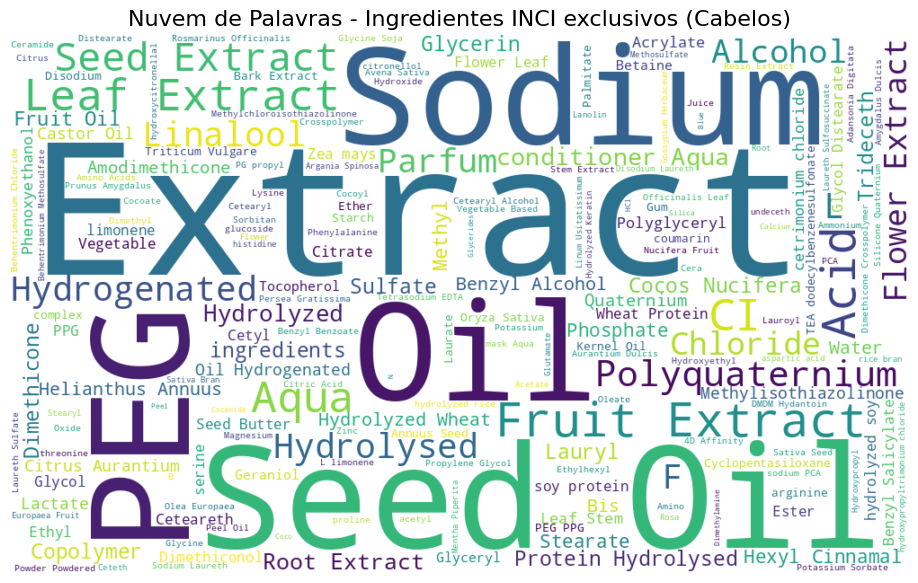

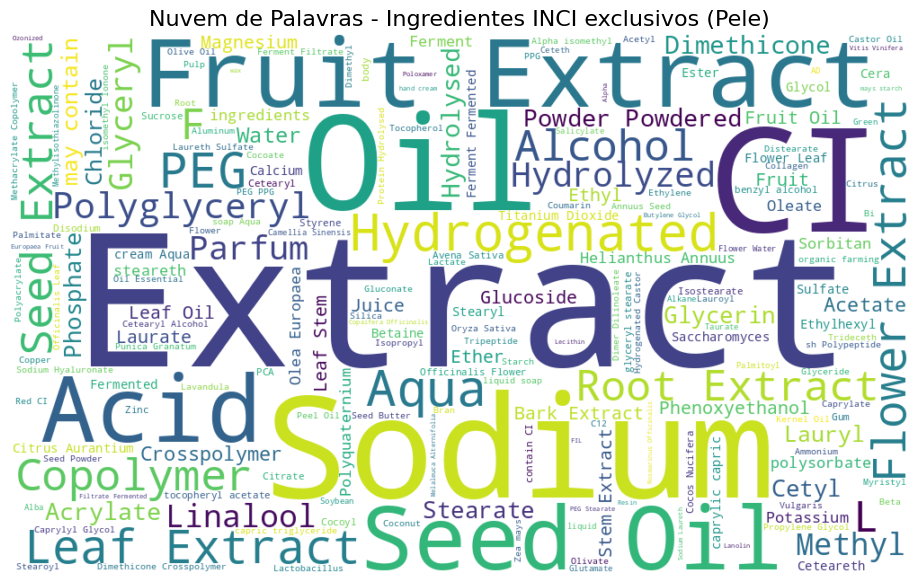

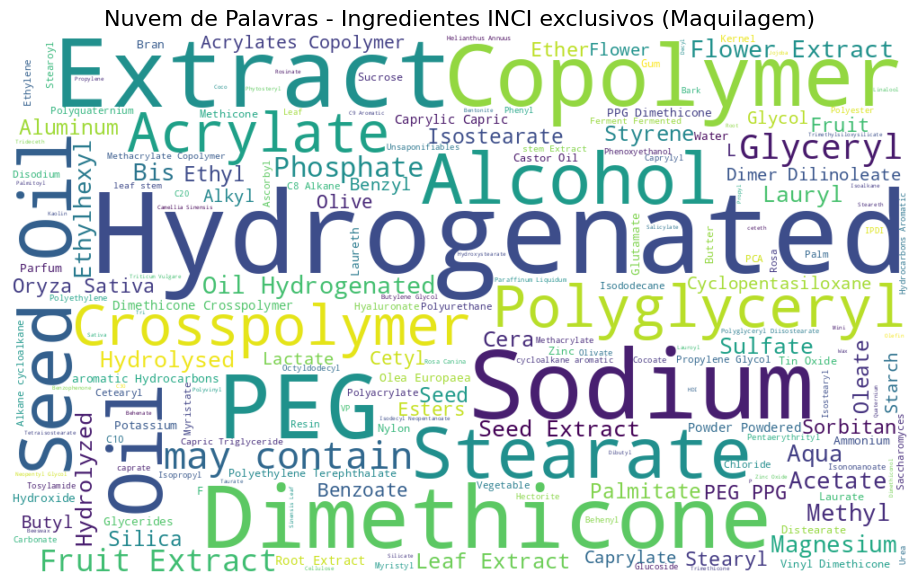

In [224]:
# Gera nuvens para as categorias, apenas para todos os ingrendientes.

# Defina a coluna de referência
coluna_ref = "Ingredients (Standard form)"  # Altere aqui se necessário

# Gera nuvens para as categorias
gerar_nuvem(ingredientes_exclusivos_por_categoria(df_launches, "Cabelos", coluna_ref), "Cabelos")
gerar_nuvem(ingredientes_exclusivos_por_categoria(df_launches, "Pele", coluna_ref), "Pele")
ingredientes_maquiagem = ingredientes_exclusivos_por_categoria(df_launches, "Maquilagem", coluna_ref)
ingredientes_maquiagem_filtrados = remover_pigmentos(ingredientes_maquiagem)
gerar_nuvem(ingredientes_maquiagem_filtrados, "Maquilagem")

##Upload INCI

In [225]:
data = '/content/'+filename2
df_inci = pd.read_excel(data)
pd.options.display.max_columns=None
df_inci.nunique()

,0
Produto,51
Ingrediente,50
Prioridade,3


## Contém Silicone?

In [226]:
pattern = '|'.join(map(re.escape, dictOTHERS.keys()))
df_launches['Silicone'] = df_launches['Ingredients (Standard form)'].str.extract(f'({pattern})', expand=False)
df_launches['Silicone'] = df_launches['Silicone'].map(dictOTHERS).fillna(0)


## Gera chave de Material


In [227]:
#Edita tabela INCI

df_inci.dropna(inplace=True)
df_inci['Produto'] = formatar_material(df_inci['Produto'])

#Cria uma lista iterável dos ingredientes nos Produtos
df_inci['Ing'] = df_inci['Ingrediente'].str.split(', ').apply(set)
df_inci.sort_values('Prioridade', ascending=True, inplace=True)

In [228]:
# Cria coluna com produtos identificados
df_launches['Ingredients (Standard form)'] = df_launches['Ingredients (Standard form)'].astype(str)
#Cria uma lista iterável das ingredientes cosmeticos
df_launches['Ing'] = (
    df_launches['Ingredients (Standard form)']
    .replace(dictIng, regex=True)
    .str.split(',')
    .apply(set)
)

# Relaciona os ingredientes cosméticos
df_launches['Prod Ident'] = df_launches['Ing'].apply(
    lambda formulacao: procura_produtos(formulacao, df_inci['Ing'], df_inci['Produto'])
)

## Gera Chave Fabricante



In [229]:
df_launches['Fabricante']= df_launches['Fabricante'].astype(str)
df_launches['Marca']= df_launches['Marca'].astype(str)
df_launches['Empresa']= df_launches['Empresa'].astype(str)
df_launches['Fabricante'] = df_launches['Fabricante'].fillna(df_launches['Empresa'])
df_launches['KeyManuf'] = gerar_chaves(df_launches, 'Fabricante', 'Empresa', 'Marca')
df_launches['KeyMarca'] = gerar_chaves(df_launches, 'Marca')
df_launches['KeyEmpresa'] = gerar_chaves(df_launches, 'Empresa')

Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'

In [230]:
# Exemplo: supondo que sua coluna de empresa é 'Fabricante'
df_launches['Estado'] = df_launches['Manufacturer Company Address'].apply(extrair_estado)

In [231]:
# Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'

missing_estado = df_launches[df_launches['Estado'].isna()]
for index, row in missing_estado.iterrows():
    keymanuf = row['KeyManuf']

    # Buscar registros com o mesmo 'KeyManuf' e 'Estado' não nulo
    estado_valido = df_launches[
        (df_launches['KeyManuf'] == keymanuf) &
        (df_launches['Estado'].notna())
    ]['Estado'].unique()

    # Se houver apenas um valor único de 'Estado', preencher
    if len(estado_valido) == 1:
        df_launches.at[index, 'Estado'] = estado_valido[0]

## Relatório de Lançamentos

In [232]:
df_launches.head()

,Número do Produto,Data de Publicação,Produto,Marca,Empresa,Categoria,Sub-Categoria,Descrição do Produto,Preço por 100g/ml,Preço em moeda local,Tipo de Lançamento,Posicionamento,Ingredients (Standard form),Fabricante,Território da empresa fabricante,Local de fabricação,Manufacturer Company Address,Link da Imagem Primária,Ano,Silicone,Ing,Prod Ident,KeyManuf,KeyMarca,KeyEmpresa,Estado
0,11306988,2024-01-02,Drying Gel,Needs Controle de Oleosidade,Instituto Pasteur de Cosmiatria,Produtos para Pele,Cuidado Facial/Pescoço,Needs Controle de Oleosidade Gel Secativo (Dry...,139.50,27.90,Nova Variedade/Extensão de Linha,"Botânico/Herbóreo, Antiacne, Testado Dermatolo...","Aqua, Alcohol, Glycerin, Propylene Glycol, Hyd...",Instituto Pasteur de Cosmiatria,Brazil,NaN,Porto Alegre - RS,https://media.mintel.com/i01/mediaserver/perfo...,2024,0,"{Hydroxyethylcellulose, Propylene Glycol, Pant...",[],instituto pasteur,needs controle,instituto pasteur,RS
1,11369612,2024-01-02,Shampoo,Elefunte Baby Cachos Perfeitinhos,Cham's Industria de Cosméticos,Produtos para Cabelos,Xampu,Elefunte Baby Cachos Perfeitinhos (Perfect Cur...,6.79,13.58,Novo Produto,"Bebês e Crianças (0-4), Botânico/Herbóreo, Hip...","Aqua, Sodium Laureth Sulfate, Sodium Cocoampho...",Cham's Industria de Cosméticos,Brazil,Brasil,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,0,"{Coumarin, L-limonene, Methylchloroisothiazoli...",[],cham's,elefunte baby,cham's,None
2,11369614,2024-01-02,Conditioner,Elefunte Baby Cachos Perfeitinhos,Cham's Industria de Cosméticos,Produtos para Cabelos,Condicionador,Elefunte Baby Cachos Perfeitinhos Condicionado...,8.75,17.50,Novo Produto,"Bebês e Crianças (0-4), Fortificado com Vitami...","Aqua, Cetyl Alcohol, Stearamidopropyl Dimethyl...",Cham's Industria de Cosméticos,Brazil,Brasil,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,1,"{Coumarin, L-limonene, Methylchloroisothiazoli...",[GB 1020],cham's,elefunte baby,cham's,None
3,11369618,2024-01-02,Conditioner,Elefunte Baby Cabelos Claros,Cham's Industria de Cosméticos,Produtos para Cabelos,Condicionador,Elefunte Baby Cabelos Claros Condicionador (Li...,8.75,17.50,Novo Produto,"Bebês e Crianças (0-4), Fortificado com Vitami...","Aqua, Cetyl Alcohol, Stearamidopropyl Dimethyl...",Cham's Industria de Cosméticos,Brazil,NaN,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,1,"{Coumarin, L-limonene, Methylchloroisothiazoli...",[GB 1020],cham's,elefunte baby,cham's,None
4,11369620,2024-01-02,Shampoo,Elefunte Baby Hora de Dormir,Cham's Industria de Cosméticos,Produtos para Cabelos,Xampu,Elefunte Baby Hora de Dormir Shampoo is now av...,6.79,13.58,Novo Produto,"Bebês e Crianças (0-4), Botânico/Herbóreo, Hip...","Aqua, Sodium Laureth Sulfate, Sodium Cocoampho...",Cham's Industria de Cosméticos,Brazil,NaN,NaN,https://media.mintel.com/i01/mediaserver/perfo...,2024,0,"{Coumarin, L-limonene, Methylchloroisothiazoli...",[],cham's,elefunte baby,cham's,None


In [233]:
df_launches['indice']=1
transpor_2(df_launches, 'Categoria', 'indice')

In [234]:
#renomeia coluna categoria
df_launches.rename(columns={'Produtos para Pele':'Pele', 'Produtos para Cabelos':'Cabelos',
                            'Maquilagem': 'Make',
                            'Número do Produto':'Total Lançamentos'},inplace=True)

In [235]:
df_c = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False)[['Pele', 'Cabelos', 'Make']].apply(lambda x:x.count())

In [236]:
#cria tabela que lista o fabricante, o estado e o total de lançamentos, quais tem silicone,
df_b = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'KeyMarca': to_set,
    'KeyEmpresa': to_set,
    'Total Lançamentos': 'count',
    'Silicone': 'count',
    'Prod Ident': to_set,
    'Ing': sinaliza_ingredientes
})

In [237]:
#Une tabelas anteriores
df_launches_fab = pd.concat([df_c, df_b], axis=1).reset_index()

In [238]:
df_launches_fab.to_excel('Relatório Lançamentos.xlsx')
df_launches_fab.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Prod Ident,Ing
0,&co e,SP,17,0,5,"[beyoung, pink cheeks, alva personal, pinkchee...","[&co e, b o, ollie, bscom brasil]",23,23,"[TMS 803, ES 3007, GB 150]","C30-45 Alkyl Methicone, Cyclomethicone, Cyclop..."
1,3fa,GO,0,1,0,[weblue],[3fa],1,1,[],"Cyclopentasiloxane, Dimethiconol"
2,5 cinco,PR,0,0,1,[5 cinco],[5 cinco],1,1,[],"Calcium Aluminum Borosilicate, Silica"
3,5s e,SP,4,0,0,"[fenzza make, quintal cultura, fenzza fiore, f...",[5s e],5,5,[],
4,a &,MG,1,0,0,[oroskin],[a &],1,1,[OW 2100],PEG-12 Dimethicone


## Agrupar relatório Vendas e Projetos

In [239]:
#agrupa lançamentos com vendas e projetos
df_launches_vend_proj = df_launches_fab.merge(df_final, on=['KeyManuf', 'Estado'], how='outer')

In [240]:
# Consolidar os dados por KeyManuf e Estado
df_consolidado = df_launches_vend_proj.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'Pele': 'sum',
    'Cabelos': 'sum',
    'Make': 'sum',
    'Total Lançamentos': 'sum',
    'Silicone': 'sum',
    'KeyMarca': to_set,
    'KeyEmpresa':to_set,
    'Prod Ident':to_set,
    'Ing':to_set,
    'Distributor_Set': to_set,
    'Sales_Qnty_2025': 'sum',
    'Sales_Kg_2025': 'sum',
    'Sales_2025': to_set
})

In [241]:
df_consolidado.head()

,,Pele,Cabelos,Make,Total Lançamentos,Silicone,KeyMarca,KeyEmpresa,Prod Ident,Ing,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,,,,,,,,,,
&co e,SP,17.0,0.0,5.0,23.0,23.0,"[beyoung, pink cheeks, alva personal, pinkchee...","[&co e, b o, ollie, bscom brasil]","[TMS 803, ES 3007, GB 150]","[C30-45 Alkyl Methicone, Cyclomethicone, Cyclo...",[FOCUS QUIMICA],3.0,398.0,"[TMS 803, EG 6000, DM 5]"
2k,SC,0.0,0.0,0.0,0.0,0.0,[],[],[],[],[EMBACAPS],2.0,70.0,"[DM 065, DM 1000]"
3fa,GO,0.0,1.0,0.0,1.0,1.0,[weblue],[3fa],[],"[Cyclopentasiloxane, Dimethiconol]",[FOCUS QUIMICA],3.0,376.0,"[OW 2100, EG 5, GB 1020]"
5 cinco,PR,0.0,0.0,1.0,1.0,1.0,[5 cinco],[5 cinco],[],"[Calcium Aluminum Borosilicate, Silica]",[],0.0,0.0,[]
5s e,SP,4.0,0.0,0.0,5.0,5.0,"[fenzza make, quintal cultura, fenzza fiore, f...",[5s e],[],[],[],0.0,0.0,[]


# Generate a Report will all information

In [242]:
df_consolidado.to_excel('Final.xlsx')